# Argentina vs Colombia - Copa America 2024

Analisis del partido utilizando event data de StatsBomb Open Data.

El objetivo es explorar el rendimiento de ambos equipos mediante datos de eventos, comenzando por tiros y xG y posteriormente incorporando pases, progresion y acciones defensivas.

In [110]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch

## Identificacion del partido

Primero se identifica la Copa America 2024 y posteriormente la final Argentina vs Colombia dentro de los datos de StatsBomb.

In [111]:
df_competiciones = pd.read_json(
    "../data/statsbomb/competitions.json"
)

df_copa_america = df_competiciones[
    (df_competiciones["competition_name"] == "Copa America") &
    (df_competiciones["season_name"] == "2024")
]

df_copa_america[
    [
        "competition_id",
        "season_id",
        "competition_name",
        "season_name"
    ]
]

,competition_id,season_id,competition_name,season_name
21,223,282,Copa America,2024


In [112]:
df_partidos = pd.read_json(
    "../data/statsbomb/matches_223_282.json"
)

In [113]:
def obtener_nombre_local(equipo):
    return equipo["home_team_name"]


def obtener_nombre_visitante(equipo):
    return equipo["away_team_name"]


df_partidos["home_team_name"] = df_partidos["home_team"].apply(
    obtener_nombre_local
)

df_partidos["away_team_name"] = df_partidos["away_team"].apply(
    obtener_nombre_visitante
)

In [114]:
df_final = df_partidos[
    (
        (df_partidos["home_team_name"] == "Argentina") &
        (df_partidos["away_team_name"] == "Colombia")
    )
    |
    (
        (df_partidos["home_team_name"] == "Colombia") &
        (df_partidos["away_team_name"] == "Argentina")
    )
]

df_final[
    [
        "match_id",
        "match_date",
        "home_team_name",
        "away_team_name",
        "home_score",
        "away_score"
    ]
]

,match_id,match_date,home_team_name,away_team_name,home_score,away_score
19,3943077,2024-07-15,Argentina,Colombia,1,0


In [115]:
match_id = df_final["match_id"].iloc[0]

match_id

np.int64(3943077)

## Eventos del partido

StatsBomb registra cada accion del partido como un evento. El dataset incluye pases, tiros, conducciones, presiones, recuperaciones, duelos y otras acciones.

Los eventos se normalizan para facilitar su analisis con Pandas.

In [116]:
with open(
    "../data/statsbomb/events_3943077.json",
    "r",
    encoding="utf-8"
) as archivo:
    datos_eventos = json.load(archivo)

In [117]:
df_eventos = pd.json_normalize(datos_eventos)

In [118]:
df_eventos.shape

(4146, 119)

In [119]:
df_eventos[
    [
        "minute",
        "second",
        "type.name",
        "team.name",
        "player.name",
        "location"
    ]
].head(10)

,minute,second,type.name,team.name,player.name,location
0,0,0,Starting XI,Argentina,NaN,NaN
1,0,0,Starting XI,Colombia,NaN,NaN
2,0,0,Half Start,Argentina,NaN,NaN
3,0,0,Half Start,Colombia,NaN,NaN
4,0,0,Pass,Argentina,Lionel Andrés Messi Cuccittini,"[61.0, 40.1]"
5,0,1,Ball Receipt*,Argentina,Enzo Fernandez,"[51.0, 40.0]"
6,0,1,Carry,Argentina,Enzo Fernandez,"[51.0, 40.0]"
7,0,2,Pass,Argentina,Enzo Fernandez,"[48.6, 41.0]"
8,0,2,Ball Receipt*,Argentina,Rodrigo Javier De Paul,"[45.6, 54.5]"
9,0,2,Carry,Argentina,Rodrigo Javier De Paul,"[45.6, 54.5]"


In [120]:
df_eventos["type.name"].value_counts()

type.name
Pass                 1197
Ball Receipt*        1114
Carry                 953
Pressure              313
Ball Recovery          93
Duel                   85
Block                  44
Goal Keeper            41
Dribble                39
Foul Committed         31
Shot                   30
Foul Won               30
Clearance              27
Dispossessed           25
Dribbled Past          23
Interception           21
Miscontrol             17
Substitution           12
Half Start              8
Half End                8
Referee Ball-Drop       8
Injury Stoppage         7
50/50                   6
Tactical Shift          4
Shield                  4
Starting XI             2
Offside                 1
Player Off              1
Player On               1
Bad Behaviour           1
Name: count, dtype: int64

## Tiros y xG

Se analizan todos los eventos de tipo `Shot`.

El xG representa la probabilidad estimada de que un remate termine en gol dadas las caracteristicas de la ocasion.

In [121]:
df_tiros = df_eventos[
    df_eventos["type.name"] == "Shot"
]

In [122]:
df_tiros_limpio = df_tiros[
    [
        "period",
        "minute",
        "second",
        "team.name",
        "player.name",
        "location",
        "shot.statsbomb_xg",
        "shot.outcome.name",
        "shot.body_part.name",
        "shot.type.name"
    ]
].copy()

In [123]:
df_tiros_limpio["x"] = df_tiros_limpio["location"].apply(
    lambda ubicacion: ubicacion[0]
)

df_tiros_limpio["y"] = df_tiros_limpio["location"].apply(
    lambda ubicacion: ubicacion[1]
)

### Produccion ofensiva por equipo

Se compara el volumen de remates, el xG acumulado y la calidad promedio de las ocasiones.

In [124]:
resumen_tiros = df_tiros_limpio.groupby("team.name").agg(
    tiros=("shot.statsbomb_xg", "count"),
    xg=("shot.statsbomb_xg", "sum")
)

resumen_tiros["xg_por_tiro"] = (
    resumen_tiros["xg"] / resumen_tiros["tiros"]
)

resumen_tiros = resumen_tiros.round(3)

resumen_tiros

,tiros,xg,xg_por_tiro
team.name,,,
Argentina,11,1.083,0.098
Colombia,19,0.972,0.051


### Produccion de tiros por jugador

Se analiza cuantos tiros realizo cada jugador, cuanto xG acumulo y la calidad promedio de sus remates.

In [125]:
resumen_jugadores = df_tiros_limpio.groupby(
    ["team.name", "player.name"]
).agg(
    tiros=("shot.statsbomb_xg", "count"),
    xg=("shot.statsbomb_xg", "sum")
)

resumen_jugadores["xg_por_tiro"] = (
    resumen_jugadores["xg"] / resumen_jugadores["tiros"]
)

resumen_jugadores = resumen_jugadores.sort_values(
    by="xg",
    ascending=False
)

resumen_jugadores = resumen_jugadores.round(3)
resumen_jugadores = resumen_jugadores.reset_index()

resumen_jugadores

,team.name,player.name,tiros,xg,xg_por_tiro
0,Argentina,Nicolás Iván González,2,0.448,0.224
1,Colombia,Carlos Eccehomo Cuesta Figueroa,3,0.320,0.107
2,Colombia,Jhon Andrés Córdoba Copete,3,0.211,0.070
3,Argentina,Lautaro Javier Martínez,1,0.199,0.199
4,Argentina,Lionel Andrés Messi Cuccittini,1,0.151,0.151
5,Colombia,Davinson Sánchez Mina,1,0.126,0.126
6,Argentina,Ángel Fabián Di María Hernández,2,0.094,0.047
7,Colombia,Jhon Adolfo Arias Andrade,3,0.084,0.028
8,Argentina,Nicolás Alejandro Tagliafico,2,0.074,0.037
9,Argentina,Julián Álvarez,1,0.072,0.072


### Resultado de los remates

In [126]:
resultados_tiros = df_tiros_limpio.groupby(
    "team.name"
)["shot.outcome.name"].value_counts()

resultados_tiros

team.name  shot.outcome.name
Argentina  Saved                4
           Off T                3
           Blocked              2
           Goal                 1
           Wayward              1
Colombia   Blocked              7
           Off T                5
           Saved                4
           Wayward              2
           Post                 1
Name: count, dtype: int64

### Ocasiones de mayor xG

In [127]:
tiros_mayor_xg = df_tiros_limpio.sort_values(
    by="shot.statsbomb_xg",
    ascending=False
)

tiros_mayor_xg[
    [
        "minute",
        "second",
        "team.name",
        "player.name",
        "shot.statsbomb_xg",
        "shot.outcome.name",
        "location"
    ]
].head(10)

,minute,second,team.name,player.name,shot.statsbomb_xg,shot.outcome.name,location
3069,92,7,Argentina,Nicolás Iván González,0.262910,Off T,"[111.1, 42.0]"
3893,111,13,Argentina,Lautaro Javier Martínez,0.198811,Goal,"[105.5, 52.1]"
3321,94,8,Argentina,Nicolás Iván González,0.185260,Saved,"[110.1, 35.3]"
476,12,7,Colombia,Carlos Eccehomo Cuesta Figueroa,0.156862,Saved,"[113.4, 38.7]"
834,19,43,Argentina,Lionel Andrés Messi Cuccittini,0.151331,Blocked,"[106.2, 36.8]"
2127,53,42,Colombia,Davinson Sánchez Mina,0.125767,Off T,"[114.8, 44.1]"
4134,121,46,Colombia,Carlos Eccehomo Cuesta Figueroa,0.106778,Wayward,"[113.8, 36.7]"
1339,33,15,Colombia,Jhon Andrés Córdoba Copete,0.085104,Blocked,"[112.5, 42.5]"
243,6,12,Colombia,Jhon Andrés Córdoba Copete,0.075898,Post,"[105.5, 47.3]"
36,0,36,Argentina,Julián Álvarez,0.072140,Off T,"[105.6, 44.0]"


## Visualizacion de tiros

Todos los remates se muestran orientados hacia el mismo arco para facilitar la comparacion espacial entre Argentina y Colombia.

El tamaño de cada marcador representa el xG de la ocasion.

In [128]:
tiros_argentina = df_tiros_limpio[
    df_tiros_limpio["team.name"] == "Argentina"
].copy()

tiros_colombia = df_tiros_limpio[
    df_tiros_limpio["team.name"] == "Colombia"
].copy()

df_goles = df_tiros_limpio[
    df_tiros_limpio["shot.outcome.name"] == "Goal"
].copy()

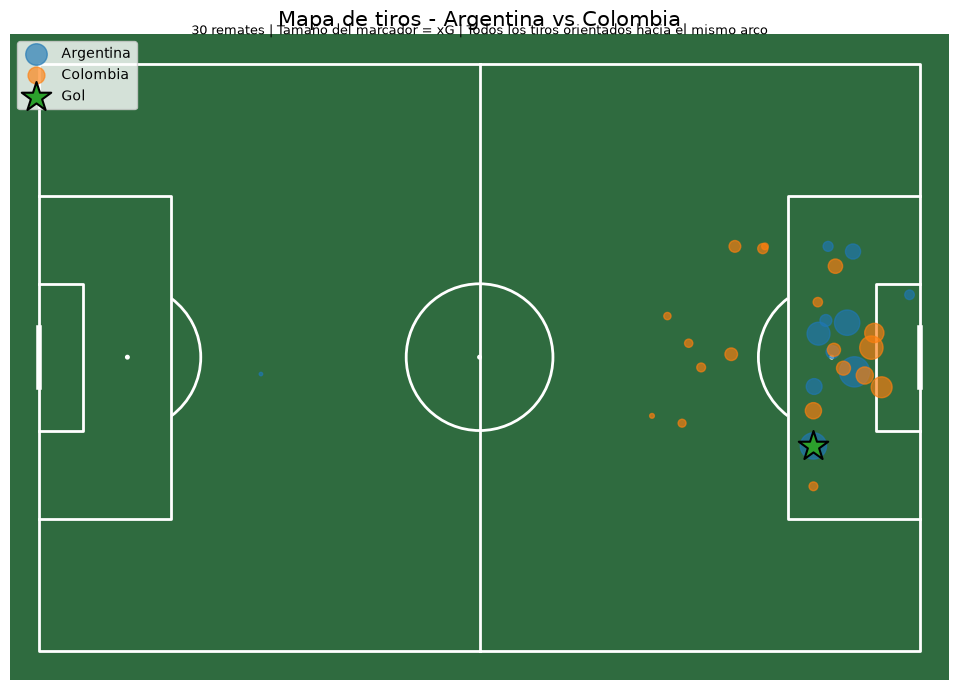

In [201]:
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#2f6b3f",
    line_color="white",
    axis=False,
    label=False
)

fig, ax = pitch.draw(figsize=(12, 7))

pitch.scatter(
    tiros_argentina["x"],
    tiros_argentina["y"],
    s=tiros_argentina["shot.statsbomb_xg"] * 1800,
    alpha=0.65,
    label="Argentina",
    ax=ax
)

pitch.scatter(
    tiros_colombia["x"],
    tiros_colombia["y"],
    s=tiros_colombia["shot.statsbomb_xg"] * 1800,
    alpha=0.65,
    label="Colombia",
    ax=ax
)

pitch.scatter(
    df_goles["x"],
    df_goles["y"],
    s=df_goles["shot.statsbomb_xg"] * 2500,
    marker="*",
    edgecolors="black",
    linewidth=1.5,
    label="Gol",
    ax=ax
)

ax.set_title(
    "Mapa de tiros - Argentina vs Colombia",
    fontsize=15
)

ax.text(
    60,
    -4,
    "30 remates | Tamaño del marcador = xG | Todos los tiros orientados hacia el mismo arco",
    ha="center",
    fontsize=9
)

ax.legend(
    loc="upper left"
)

plt.savefig(
    "../outputs/figures/shot_map_argentina_colombia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Pases y progresion

Se analizan los eventos de pase de ambos equipos, considerando volumen, precision, creacion de ocasiones y progresion territorial.

Las metricas se calculan a partir de los eventos y coordenadas proporcionados por StatsBomb.

In [130]:
df_pases = df_eventos[
    df_eventos["type.name"] == "Pass"
].copy()

df_pases.shape

(1197, 119)

In [131]:
[
    columna
    for columna in df_pases.columns
    if columna.startswith("pass.")
]

['pass.recipient.id',
 'pass.recipient.name',
 'pass.length',
 'pass.angle',
 'pass.height.id',
 'pass.height.name',
 'pass.end_location',
 'pass.body_part.id',
 'pass.body_part.name',
 'pass.type.id',
 'pass.type.name',
 'pass.switch',
 'pass.outcome.id',
 'pass.outcome.name',
 'pass.cross',
 'pass.assisted_shot_id',
 'pass.shot_assist',
 'pass.outswinging',
 'pass.technique.id',
 'pass.technique.name',
 'pass.miscommunication',
 'pass.aerial_won',
 'pass.inswinging',
 'pass.cut_back',
 'pass.through_ball',
 'pass.goal_assist']

In [132]:
df_pases.shape

(1197, 119)

In [133]:
df_pases_limpio = df_pases[
    [
        "period",
        "minute",
        "second",
        "team.name",
        "player.name",
        "location",
        "pass.recipient.name",
        "pass.end_location",
        "pass.length",
        "pass.outcome.name",
        "pass.type.name",
        "pass.shot_assist",
        "pass.goal_assist"
    ]
].copy()

In [134]:
df_pases_limpio["pass.type.name"].value_counts(
    dropna=False
)

pass.type.name
NaN             995
Recovery         96
Throw-in         35
Free Kick        27
Goal Kick        21
Corner           11
Interception      7
Kick Off          5
Name: count, dtype: int64

In [135]:
df_pases_limpio["x"] = df_pases_limpio["location"].apply(
    lambda ubicacion: ubicacion[0]
)

df_pases_limpio["y"] = df_pases_limpio["location"].apply(
    lambda ubicacion: ubicacion[1]
)

df_pases_limpio["end_x"] = df_pases_limpio["pass.end_location"].apply(
    lambda ubicacion: ubicacion[0]
)

df_pases_limpio["end_y"] = df_pases_limpio["pass.end_location"].apply(
    lambda ubicacion: ubicacion[1]
)

In [136]:
df_pases_limpio["pass.outcome.name"].value_counts(
    dropna=False
)

pass.outcome.name
NaN             992
Incomplete      175
Out              22
Unknown           6
Pass Offside      2
Name: count, dtype: int64

In [179]:
df_pases_limpio["completado"] = (
    df_pases_limpio["pass.outcome.name"].isna()
)

In [180]:
df_pases_limpio["contabilizable"] = (
    df_pases_limpio["pass.type.name"] != "Throw-in"
)

df_pases_limpio["completado_contabilizable"] = (
    df_pases_limpio["completado"]
    &
    df_pases_limpio["contabilizable"]
)

### Definiciones de pases

**Pase completado:** StatsBomb registra generalmente un pase exitoso sin valor en `pass.outcome.name`. Para las estadisticas generales de pase se incluyen acciones de juego abierto, tiros libres, corners, saques de arco y saques iniciales. Los laterales no se contabilizan como pases intentados ni completados.

**Pase en juego:** pase realizado mientras el balon esta en juego. Se excluyen las reanudaciones: saques de arco, tiros libres, corners, laterales y saques iniciales.

**Pase clave:** pase que conduce directamente a un remate, independientemente de si el remate termina en gol.

**Asistencia:** pase clave cuyo remate posterior termina en gol. Por lo tanto, las asistencias estan incluidas dentro de los pases clave.

Las metricas de pases clave y asistencias se consideran de forma independiente al criterio utilizado para contabilizar el volumen general de pases.

In [181]:
tipos_reanudacion = [
    "Throw-in",
    "Free Kick",
    "Goal Kick",
    "Corner",
    "Kick Off"
]

df_pases_limpio["en_juego"] = (
    ~df_pases_limpio["pass.type.name"].isin(tipos_reanudacion)
)

In [182]:
df_pases_limpio[
    [
        "team.name",
        "player.name",
        "pass.recipient.name",
        "pass.type.name",
        "pass.outcome.name",
        "completado",
        "contabilizable",
        "completado_contabilizable",
        "en_juego"
    ]
].head(15)

,team.name,player.name,pass.recipient.name,pass.type.name,pass.outcome.name,completado,contabilizable,completado_contabilizable,en_juego
4,Argentina,Lionel Andrés Messi Cuccittini,Enzo Fernandez,Kick Off,NaN,True,True,True,False
7,Argentina,Enzo Fernandez,Rodrigo Javier De Paul,NaN,NaN,True,True,True,True
10,Argentina,Rodrigo Javier De Paul,Cristian Gabriel Romero,NaN,NaN,True,True,True,True
13,Argentina,Cristian Gabriel Romero,Nicolás Alejandro Tagliafico,NaN,NaN,True,True,True,True
16,Argentina,Nicolás Alejandro Tagliafico,Lisandro Martínez,NaN,NaN,True,True,True,True
19,Argentina,Lisandro Martínez,Damián Emiliano Martínez,NaN,NaN,True,True,True,True
23,Argentina,Damián Emiliano Martínez,Lionel Andrés Messi Cuccittini,NaN,Incomplete,False,True,False,True
25,Colombia,Carlos Eccehomo Cuesta Figueroa,NaN,Recovery,Incomplete,False,True,False,True
26,Argentina,Enzo Fernandez,Lionel Andrés Messi Cuccittini,Recovery,NaN,True,True,True,True
31,Argentina,Lionel Andrés Messi Cuccittini,Gonzalo Ariel Montiel,NaN,NaN,True,True,True,True


In [183]:
df_pases_limpio["asistencia"] = (
    df_pases_limpio["pass.goal_assist"].eq(True)
)

df_pases_limpio["pase_clave"] = (
    df_pases_limpio["pass.shot_assist"].eq(True)
    |
    df_pases_limpio["asistencia"]
)

### Resumen de pases por equipo

Se comparan el volumen de pases, los pases completados, la precision, la longitud media, los pases clave y las asistencias de ambos equipos.

In [184]:
df_pases_limpio["longitud_contabilizable"] = (
    df_pases_limpio["pass.length"].where(
        df_pases_limpio["contabilizable"]
    )
)

In [185]:
resumen_pases = df_pases_limpio.groupby("team.name").agg(
    pases_intentados=("contabilizable", "sum"),
    pases_completados=("completado_contabilizable", "sum"),
    longitud_media=("longitud_contabilizable", "mean"),
    pases_clave=("pase_clave", "sum"),
    asistencias=("asistencia", "sum")
)

resumen_pases["precision"] = (
    resumen_pases["pases_completados"]
    / resumen_pases["pases_intentados"]
    * 100
)

resumen_pases = resumen_pases.round(2)

resumen_pases

,pases_intentados,pases_completados,longitud_media,pases_clave,asistencias,precision
team.name,,,,,,
Argentina,521,422,20.94,11,1,81.00
Colombia,641,539,21.44,15,0,84.09


In [143]:
resumen_pases["precision"] = (
    resumen_pases["pases_completados"]
    / resumen_pases["pases_intentados"]
    * 100
)

resumen_pases = resumen_pases.round(2)

resumen_pases

,pases_intentados,pases_completados,longitud_media,pases_clave,asistencias,precision
team.name,,,,,,
Argentina,537,436,20.76,11,1,81.19
Colombia,660,556,21.41,15,0,84.24


### Pases progresivos

Se considera pase progresivo a un pase completado con el balon en juego que reduce al menos un 25% la distancia restante entre el balon y el centro del arco rival.

Se excluyen de esta metrica las reanudaciones de juego: saques de arco, tiros libres, corners, laterales y saques iniciales.

In [155]:
df_pases_en_juego = df_pases_limpio[
    df_pases_limpio["en_juego"]
].copy()

In [156]:
df_pases_en_juego["distancia_arco_inicio"] = np.sqrt(
    (120 - df_pases_en_juego["x"]) ** 2
    +
    (40 - df_pases_en_juego["y"]) ** 2
)

df_pases_en_juego["distancia_arco_fin"] = np.sqrt(
    (120 - df_pases_en_juego["end_x"]) ** 2
    +
    (40 - df_pases_en_juego["end_y"]) ** 2
)

df_pases_en_juego["reduccion_distancia_arco"] = (
    df_pases_en_juego["distancia_arco_inicio"]
    -
    df_pases_en_juego["distancia_arco_fin"]
) / df_pases_en_juego["distancia_arco_inicio"]

df_pases_en_juego["progresivo"] = (
    df_pases_en_juego["completado"]
    &
    (df_pases_en_juego["reduccion_distancia_arco"] >= 0.25)
)

In [157]:
df_pases_en_juego[
    [
        "team.name",
        "player.name",
        "pass.type.name",
        "x",
        "y",
        "end_x",
        "end_y",
        "distancia_arco_inicio",
        "distancia_arco_fin",
        "reduccion_distancia_arco",
        "completado",
        "progresivo"
    ]
].head(20)

,team.name,player.name,pass.type.name,x,y,end_x,end_y,distancia_arco_inicio,distancia_arco_fin,reduccion_distancia_arco,completado,progresivo
7,Argentina,Enzo Fernandez,NaN,48.6,41.0,45.6,54.5,71.407002,75.799802,-0.061518,True,False
10,Argentina,Rodrigo Javier De Paul,NaN,45.6,54.5,31.1,55.4,75.799802,90.223999,-0.190293,True,False
13,Argentina,Cristian Gabriel Romero,NaN,32.6,52.8,50.7,6.2,88.332327,77.103372,0.127122,True,False
16,Argentina,Nicolás Alejandro Tagliafico,NaN,49.7,6.4,27.0,21.6,77.916943,94.802743,-0.216715,True,False
19,Argentina,Lisandro Martínez,NaN,28.5,22.6,17.2,42.7,93.139734,102.835451,-0.104099,True,False
23,Argentina,Damián Emiliano Martínez,NaN,19.5,45.1,83.0,58.3,100.629320,41.278202,0.589799,False,False
25,Colombia,Carlos Eccehomo Cuesta Figueroa,Recovery,37.1,21.8,66.0,29.5,84.874319,55.011362,0.351849,False,False
26,Argentina,Enzo Fernandez,Recovery,54.1,50.6,72.2,55.0,66.747060,50.098303,0.249431,True,False
31,Argentina,Lionel Andrés Messi Cuccittini,NaN,72.4,62.7,88.4,77.9,52.735662,49.345415,0.064288,True,False
34,Argentina,Gonzalo Ariel Montiel,NaN,106.5,68.5,105.6,44.0,31.535694,14.945233,0.526085,True,True


In [186]:
resumen_progresion = df_pases_en_juego.groupby("team.name").agg(
    pases_completados_en_juego=("completado", "sum"),
    pases_progresivos=("progresivo", "sum")
)

resumen_progresion["pases_completados"] = (
    resumen_pases["pases_completados"]
)

resumen_progresion["porcentaje_progresivos"] = (
    resumen_progresion["pases_progresivos"]
    / resumen_progresion["pases_completados_en_juego"]
    * 100
)

resumen_progresion = resumen_progresion[
    [
        "pases_completados",
        "pases_completados_en_juego",
        "pases_progresivos",
        "porcentaje_progresivos"
    ]
]

resumen_progresion = resumen_progresion.round(2)

resumen_progresion

,pases_completados,pases_completados_en_juego,pases_progresivos,porcentaje_progresivos
team.name,,,,
Argentina,422,396,33,8.33
Colombia,539,519,51,9.83


In [192]:
resumen_pases_jugadores = df_pases_limpio.groupby(
    ["team.name", "player.name"]
).agg(
    pases_completados=("completado_contabilizable", "sum")
)

In [193]:
resumen_progresion_jugadores = df_pases_en_juego.groupby(
    ["team.name", "player.name"]
).agg(
    pases_completados_en_juego=("completado", "sum"),
    pases_progresivos=("progresivo", "sum")
)

In [194]:
resumen_progresion_jugadores = resumen_pases_jugadores.join(
    resumen_progresion_jugadores,
    how="left"
).fillna(0)

In [195]:
resumen_progresion_jugadores["porcentaje_progresivos"] = (
    resumen_progresion_jugadores["pases_progresivos"]
    / resumen_progresion_jugadores["pases_completados_en_juego"]
    * 100
)

In [196]:
resumen_progresion_jugadores = resumen_progresion_jugadores.sort_values(
    by="pases_progresivos",
    ascending=False
)

resumen_progresion_jugadores = resumen_progresion_jugadores.round(2)

resumen_progresion_jugadores = resumen_progresion_jugadores.reset_index()

resumen_progresion_jugadores

,team.name,player.name,pases_completados,pases_completados_en_juego,pases_progresivos,porcentaje_progresivos
0,Colombia,Jefferson Andrés Lerma Solís,56,55,8,14.55
1,Colombia,James David Rodríguez Rubio,52,48,7,14.58
2,Colombia,Davinson Sánchez Mina,70,70,7,10.00
3,Colombia,Johan Andrés Mojica Palacio,53,53,7,13.21
4,Argentina,Ángel Fabián Di María Hernández,34,32,6,18.75
5,Colombia,Jorge Andrés Carrascal Guardo,13,13,4,30.77
6,Argentina,Leandro Daniel Paredes,8,7,4,57.14
7,Argentina,Lionel Andrés Messi Cuccittini,28,26,4,15.38
8,Argentina,Rodrigo Javier De Paul,46,45,4,8.89
9,Colombia,Jhon Adolfo Arias Andrade,51,50,4,8.00


### Principales pasadores progresivos

Se muestran los jugadores con mayor cantidad de pases progresivos completados durante el partido.

El porcentaje progresivo se calcula sobre los pases completados en juego, no sobre el total de pases completados.

In [197]:
top_progresivos = resumen_progresion_jugadores.head(10)

top_progresivos

,team.name,player.name,pases_completados,pases_completados_en_juego,pases_progresivos,porcentaje_progresivos
0,Colombia,Jefferson Andrés Lerma Solís,56,55,8,14.55
1,Colombia,James David Rodríguez Rubio,52,48,7,14.58
2,Colombia,Davinson Sánchez Mina,70,70,7,10.00
3,Colombia,Johan Andrés Mojica Palacio,53,53,7,13.21
4,Argentina,Ángel Fabián Di María Hernández,34,32,6,18.75
5,Colombia,Jorge Andrés Carrascal Guardo,13,13,4,30.77
6,Argentina,Leandro Daniel Paredes,8,7,4,57.14
7,Argentina,Lionel Andrés Messi Cuccittini,28,26,4,15.38
8,Argentina,Rodrigo Javier De Paul,46,45,4,8.89
9,Colombia,Jhon Adolfo Arias Andrade,51,50,4,8.00


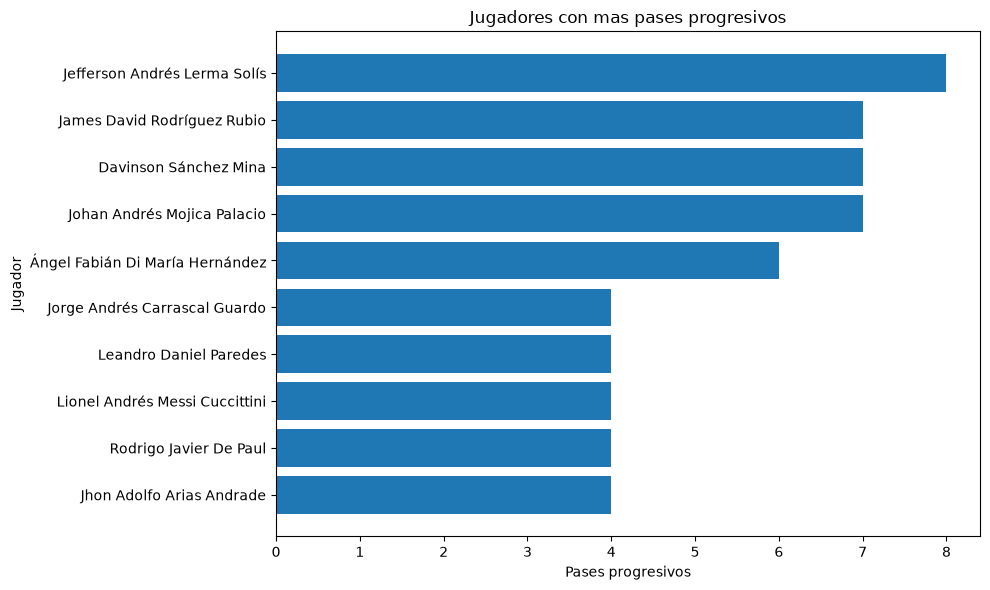

In [198]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_progresivos["player.name"],
    top_progresivos["pases_progresivos"]
)

ax.set_xlabel("Pases progresivos")
ax.set_ylabel("Jugador")
ax.set_title("Jugadores con mas pases progresivos")

ax.invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/pases_progresivos_argentina_colombia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Mapas de pases por equipo

Se representan los pases contabilizables de cada equipo durante el partido.

Los pases completados se muestran en verde y los no completados en rojo. Los laterales se excluyen de acuerdo con la definicion utilizada para las estadisticas generales de pase.

In [202]:
df_pases_mapa = df_pases_limpio[
    df_pases_limpio["contabilizable"]
].copy()

In [207]:
def crear_mapa_pases_equipo(df_pases, equipo, archivo_salida):
    pases_equipo = df_pases[
        df_pases["team.name"] == equipo
    ].copy()

    pases_completados = pases_equipo[
        pases_equipo["completado"]
    ]

    pases_no_completados = pases_equipo[
        ~pases_equipo["completado"]
    ]

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#2f6b3f",
        line_color="white",
        axis=False,
        label=False
    )

    fig, ax = pitch.draw(figsize=(12, 8))

    pitch.arrows(
        pases_completados["x"],
        pases_completados["y"],
        pases_completados["end_x"],
        pases_completados["end_y"],
        color="#7CFC00",
        width=1,
        headwidth=3,
        headlength=3,
        alpha=0.30,
        label="Completado",
        ax=ax
    )

    pitch.arrows(
        pases_no_completados["x"],
        pases_no_completados["y"],
        pases_no_completados["end_x"],
        pases_no_completados["end_y"],
        color="#ff4040",
        width=1.2,
        headwidth=3,
        headlength=3,
        alpha=0.65,
        label="No completado",
        ax=ax
    )

    ax.set_title(
        f"Mapa de pases - {equipo}",
        fontsize=15,
        color="black"
    )

    ax.legend(
        loc="upper left"
    )

    plt.savefig(
        archivo_salida,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

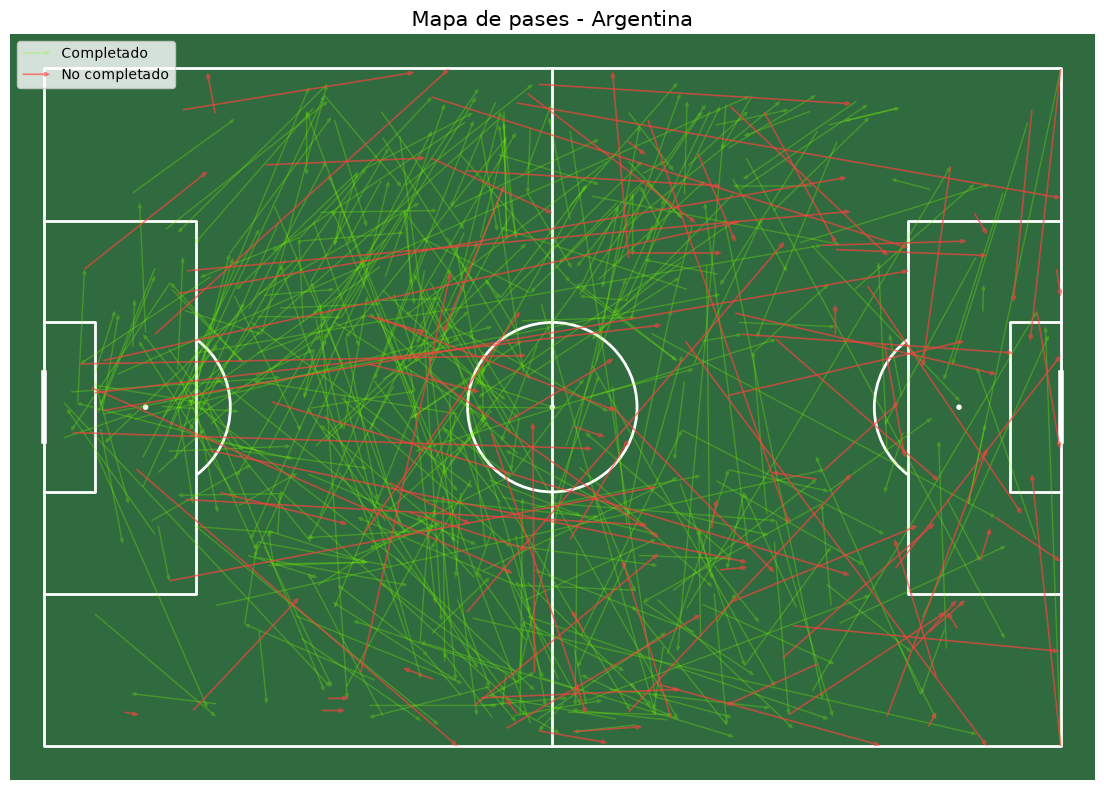

In [208]:
crear_mapa_pases_equipo(
    df_pases_mapa,
    "Argentina",
    "../outputs/figures/mapa_pases_argentina.png"
)

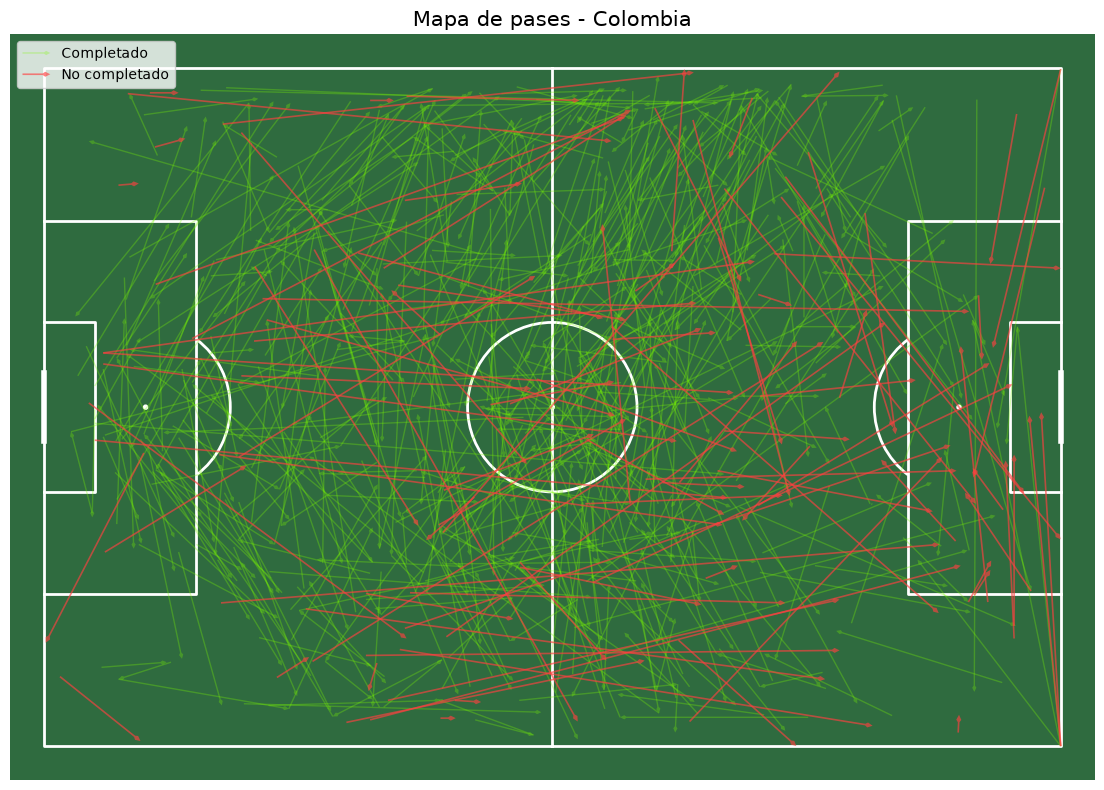

In [209]:
crear_mapa_pases_equipo(
    df_pases_mapa,
    "Colombia",
    "../outputs/figures/mapa_pases_colombia.png"
)

## Acciones defensivas y territorio